In [ ]:
# Cell 1: Install Dependencies (CUDA + ONNX export deps)
%pip install --upgrade pip -q
%pip install --upgrade torch torchvision --index-url https://download.pytorch.org/whl/cu128
%pip install albumentations grad-cam scikit-learn matplotlib seaborn tqdm opencv-python ipywidgets onnx onnxscript -q
print(' CUDA-enabled packages installed, including onnx + onnxscript.')

Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu128
   ---------------------------------------- 0.0/2.8 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 GB 20.2 MB/s eta 0:02:17
   ---------------------------------------- 0.0/2.8 GB 20.5 MB/s eta 0:02:15
   ---------------------------------------- 0.0/2.8 GB 19.9 MB/s eta 0:02:18
   ---------------------------------------- 0.0/2.8 GB 21.5 MB/s eta 0:02:08
   ---------------------------------------- 0.0/2.8 GB 23.1 MB/s eta 0:01:59
   ---------------------------------------- 0.0/2.8 GB 25.2 MB/s eta 0:01:49
    --------------------------------------- 0.0/2.8 GB 25.6 MB/s eta 0:01:47
    --------------------------------------- 0.0/2.8 GB 25.3 MB/s eta 0:01:48
    --------------------------------------- 0.0/2.8 GB 25.5 MB/s eta 0:01:47
    --------------------------------------- 0.0/2.8 GB 22.3 MB/s eta 0:02:02
    --------------------------------

  You can safely remove it manually.
  You can safely remove it manually.


Note: you may need to restart the kernel to use updated packages.
 CUDA-enabled packages installed (if compatible GPU/driver is available).


In [1]:
# Cell 2: Imports
import os, json, random, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
from collections import Counter
from tqdm.auto import tqdm
import zipfile

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models
from torchvision.models import ResNet50_Weights

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

# Device selection (prefer GPU, fail fast if unavailable)
REQUIRE_GPU = True
if REQUIRE_GPU and not torch.cuda.is_available():
    raise RuntimeError(
        "GPU requested but CUDA is not available. "
        "Install a CUDA-enabled PyTorch build and make sure NVIDIA drivers are installed."
    )

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'  Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   CUDA: {torch.version.cuda}')

  Device: cuda:0
   GPU: NVIDIA GeForce RTX 3050 Laptop GPU
   CUDA: 12.8


In [2]:
# Cell 3: Verify CUDA
import torch
print('torch version :', torch.__version__)
print('cuda version  :', torch.version.cuda)
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('gpu name      :', torch.cuda.get_device_name(0))
else:
    print('No CUDA GPU detected by current environment.')

torch version : 2.11.0+cu128
cuda version  : 12.8
cuda available: True
gpu name      : NVIDIA GeForce RTX 3050 Laptop GPU


In [4]:
# Cell 3: Configuration
ZIP_PATH = './IP102-Dataset.zip'
DATA_DIR = './dataset'

# Extract dataset if needed
if not os.path.exists(os.path.join(DATA_DIR, 'classification')):
    print(f"Extracting {ZIP_PATH}...")
    os.makedirs(DATA_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
    print(" Dataset extracted!")

# Get class names
def get_classes_from_zip(zip_path):
    if not os.path.exists(zip_path):
        return [str(i) for i in range(102)]
    with zipfile.ZipFile(zip_path, 'r') as z:
        content = z.read('classes.txt').decode('utf-8')
    lines = [line.strip() for line in content.strip().split('\n') if line.strip()]
    return [line.split(maxsplit=1)[1].strip() for line in lines if len(line.split(maxsplit=1)) == 2]

class_names = get_classes_from_zip(ZIP_PATH)

# Set data directory
base_dir = os.path.join(DATA_DIR, 'classification')
if os.path.exists(base_dir):
    DATA_DIR = base_dir

CFG = {
    'data_dir': DATA_DIR,
    'zip_path': ZIP_PATH,
    'num_classes': len(class_names),
    'class_names': class_names,
    
    'img_size': 224,
    'mean': [0.485, 0.456, 0.406],
    'std': [0.229, 0.224, 0.225],
    
    'batch_size': 16,  # Reduced for speed
    'num_workers': 0,  # Set to 0 to avoid multiprocessing issues
    'pin_memory': False,
    
    'phase1_epochs': 3,  # Reduced for testing
    'phase1_lr': 1e-3,
    'phase2_epochs': 10,
    'phase2_lr_head': 1e-3,
    'phase2_lr_back': 1e-4,
    'weight_decay': 1e-4,
    'grad_clip': 1.0,
    'early_stop_patience': 5,
    
    'focal_gamma': 2.0,
    'focal_alpha': 0.25,
    'label_smoothing': 0.1,
    
    'use_mixup': True,
    'mixup_alpha': 0.2,
    
    'checkpoint_path': './best_model.pth',
    'results_dir': './results',
}

os.makedirs(CFG['results_dir'], exist_ok=True)
print(f' Config loaded - {CFG["num_classes"]} classes')

 Config loaded - 102 classes


In [5]:
# Cell 4: Data Augmentation
IMG_SIZE = CFG['img_size']
MEAN, STD = CFG['mean'], CFG['std']

train_transform = A.Compose([
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.7, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.3),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

print(' Augmentation pipelines ready')

 Augmentation pipelines ready


In [6]:
# Cell 5: Simple Fast Dataset (REPLACES YOUR OLD DATASET)
class PestDataset(Dataset):
    """Simple and fast dataset loader"""
    IMG_EXTS = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}
    
    def __init__(self, data_dir, split='train', transform=None, class_names=None, max_samples=None):
        self.transform = transform
        self.samples = []
        
        data_path = Path(data_dir)
        split_path = data_path / split
        
        if not split_path.exists():
            split_path = data_path
        
        # Get all class folders
        class_dirs = sorted([d for d in split_path.iterdir() if d.is_dir()])
        
        if class_names is None:
            self.classes = [d.name for d in class_dirs]
        else:
            self.classes = class_names
        
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        
        # Collect all image paths
        print(f'Scanning {split} folder...')
        for cls_dir in class_dirs:
            cls_name = cls_dir.name
            
            # Get label
            if cls_name.isdigit():
                label = int(cls_name)
                if label >= len(self.classes):
                    continue
            else:
                if cls_name not in self.class_to_idx:
                    continue
                label = self.class_to_idx[cls_name]
            
            # Get images
            images = []
            for ext in self.IMG_EXTS:
                images.extend(list(cls_dir.glob(f'*{ext}')))
            
            for img_path in images:
                self.samples.append((str(img_path), label))
        
        # Limit samples if specified
        if max_samples and len(self.samples) > max_samples:
            random.shuffle(self.samples)
            self.samples = self.samples[:max_samples]
        
        print(f'[{split}] {len(self.samples)} images loaded')
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        
        # Load image
        img = cv2.imread(img_path)
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Apply transforms
        if self.transform:
            try:
                img = self.transform(image=img)['image']
            except:
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        
        return img, label

print(' Fast dataset class ready')

 Fast dataset class ready


In [7]:
# Cell 6: Create Datasets and DataLoaders
print("Creating datasets...")

# Use subset for faster testing (remove max_samples for full training)
train_ds = PestDataset(CFG['data_dir'], split='train', transform=train_transform, 
                       class_names=CFG['class_names'], max_samples=5000)  # Limit to 5000 for testing

val_ds = PestDataset(CFG['data_dir'], split='val', transform=val_transform, 
                     class_names=CFG['class_names'], max_samples=1000)

test_ds = PestDataset(CFG['data_dir'], split='test', transform=val_transform, 
                      class_names=CFG['class_names'], max_samples=1000)

# Create loaders with minimal settings for speed
train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True, 
                          num_workers=0, pin_memory=False)
val_loader = DataLoader(val_ds, batch_size=CFG['batch_size']*2, shuffle=False, 
                        num_workers=0, pin_memory=False)
test_loader = DataLoader(test_ds, batch_size=CFG['batch_size']*2, shuffle=False, 
                         num_workers=0, pin_memory=False)

print(f'\n DataLoaders ready')
print(f'   Train: {len(train_ds)} images, {len(train_loader)} batches')
print(f'   Val: {len(val_ds)} images, {len(val_loader)} batches')
print(f'   Test: {len(test_ds)} images, {len(test_loader)} batches')

# Quick test
print('\nTesting batch loading...')
start = time.time()
batch = next(iter(train_loader))
print(f' Batch loaded in {time.time()-start:.2f}s')
print(f'   Image shape: {batch[0].shape}')
print(f'   Label shape: {batch[1].shape}')

Creating datasets...
Scanning train folder...
[train] 5000 images loaded
Scanning val folder...
[val] 1000 images loaded
Scanning test folder...
[test] 1000 images loaded

 DataLoaders ready
   Train: 5000 images, 313 batches
   Val: 1000 images, 32 batches
   Test: 1000 images, 32 batches

Testing batch loading...
 Batch loaded in 0.14s
   Image shape: torch.Size([16, 3, 224, 224])
   Label shape: torch.Size([16])


In [8]:
# Cell 7: Build Model
def build_model(num_classes):
    weights = ResNet50_Weights.IMAGENET1K_V2
    model = models.resnet50(weights=weights)
    
    # Replace final layer
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    return model

model = build_model(CFG['num_classes'])
model = model.to(DEVICE)

print(f' Model built')
print(f'   Total params: {sum(p.numel() for p in model.parameters()):,}')

# Test forward pass
print('Testing forward pass...')
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f' Forward pass works! Output shape: {out.shape}')

 Model built
   Total params: 24,609,446
Testing forward pass...
 Forward pass works! Output shape: torch.Size([1, 102])


In [14]:
# Cell 8 (REPLACED): Better Loss Function & Training
import math

class ImprovedFocalLoss(nn.Module):
    """Focal Loss with label smoothing for better generalization"""
    def __init__(self, gamma=2.0, alpha=0.25, label_smoothing=0.1, num_classes=102):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.label_smoothing = label_smoothing
        self.num_classes = num_classes
    
    def forward(self, inputs, targets):
        # Label smoothing
        smooth = self.label_smoothing / self.num_classes
        one_hot = torch.zeros_like(inputs).scatter_(1, targets.unsqueeze(1), 1.0)
        soft_targets = one_hot * (1.0 - self.label_smoothing) + smooth
        
        # Focal loss
        log_probs = F.log_softmax(inputs, dim=1)
        probs = log_probs.exp()
        
        # Focal weight: focus on hard examples
        pt = (probs * one_hot).sum(dim=1)
        focal_weight = (1.0 - pt) ** self.gamma
        
        # Compute loss
        loss = -(soft_targets * log_probs).sum(dim=1)
        loss = self.alpha * focal_weight * loss
        
        return loss.mean()

criterion = ImprovedFocalLoss(
    gamma=2.0, 
    alpha=0.25, 
    label_smoothing=0.1,  # This helps prevent overfitting
    num_classes=CFG['num_classes']
)

print(' Improved Focal Loss with label smoothing ready')

 Improved Focal Loss with label smoothing ready


In [15]:
# Cell 8.5 (NEW): MixUp Augmentation
def mixup_data(x, y, alpha=0.4):
    """MixUp: blends two images and their labels"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    
    return mixed_x, y_a, y_b, lam

def mixup_loss(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print(' MixUp augmentation ready')

 MixUp augmentation ready


In [16]:
# Cell 9 (REPLACED): Better Training Loop with Regularization
def train_epoch(model, loader, optimizer, use_mixup=True):
    """Training with MixUp and gradient clipping"""
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        # Apply MixUp (50% chance)
        if use_mixup and np.random.random() < 0.5:
            images, labels_a, labels_b, lam = mixup_data(images, labels, alpha=0.2)
            mixed = True
        else:
            mixed = False
        
        optimizer.zero_grad(set_to_none=True)  # More efficient
        
        outputs = model(images)
        
        if mixed:
            loss = mixup_loss(criterion, outputs, labels_a, labels_b, lam)
        else:
            loss = criterion(outputs, labels)
        
        loss.backward()
        
        # Gradient clipping prevents overfitting
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        # Track metrics (only on non-mixed for accuracy)
        total_loss += loss.item() * images.size(0)
        with torch.no_grad():
            _, preds = outputs.max(1)
            if not mixed:
                correct += preds.eq(labels).sum().item()
                total += images.size(0)
            else:
                # For mixed, count correctly predicted as average
                correct += (lam * preds.eq(labels_a).float() + 
                           (1-lam) * preds.eq(labels_b).float()).sum().item()
                total += images.size(0)
        
        if (batch_idx + 1) % 20 == 0:
            print(f'  Batch {batch_idx+1}/{len(loader)} - Loss: {loss.item():.4f} - Acc: {correct/max(1,total):.3f}')
    
    return total_loss / max(1, total), correct / max(1, total)

@torch.no_grad()
def validate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    
    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        total_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += images.size(0)
    
    return total_loss / total, correct / total

print(' Improved training functions with MixUp and gradient clipping ready')

 Improved training functions with MixUp and gradient clipping ready


In [20]:
# Cell X: KILL CURRENT TRAINING AND RESTART WITH THIS
print("="*60)
print("RESTARTING TRAINING WITH ANTI-OVERFITTING MEASURES")
print("="*60)

# 1. Reload fresh model (discard overfitted weights)
model = build_model(CFG['num_classes'])
model = model.to(DEVICE)
print(" Fresh model loaded")

# 2. FREEZE MORE LAYERS - Only train last 2 blocks
print("\nFreezing early layers to prevent overfitting...")
for name, param in model.named_parameters():
    # Freeze everything except layer4 and fc
    if 'layer4' not in name and 'fc' not in name:
        param.requires_grad = False
    else:
        param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)")

# 3. STRONGER DATA AUGMENTATION
print("\nCreating aggressive augmentation...")
aggressive_transform = A.Compose([
    A.RandomResizedCrop(size=(224, 224), scale=(0.4, 1.0)),  # More aggressive cropping
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=45, p=0.5),  # More rotation
    A.OneOf([
        A.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3),
        A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20),
    ], p=0.7),
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 9)),
        A.GaussNoise(var_limit=(10.0, 60.0)),
        A.MotionBlur(blur_limit=(3, 7)),
    ], p=0.4),
    A.CoarseDropout(
        num_holes_range=(1, 12),  # More holes
        hole_height_range=(1, 40),
        hole_width_range=(1, 40),
        fill=0, p=0.4  # Higher probability
    ),
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),
    A.CLAHE(clip_limit=2.0, p=0.3),
    A.Normalize(mean=CFG['mean'], std=CFG['std']),
    ToTensorV2(),
])

# Recreate datasets
train_ds_aug = PestDataset(
    CFG['data_dir'], split='train',
    transform=aggressive_transform,
    class_names=CFG['class_names'],
    max_samples=None  # USE ALL DATA
)

train_loader_aug = DataLoader(
    train_ds_aug, batch_size=CFG['batch_size'],
    shuffle=True, num_workers=0, pin_memory=False
)

print(f" Aggressive augmentation ready: {len(train_ds_aug)} images")

# 4. USE CROSS ENTROPY INSTEAD OF FOCAL LOSS
# Focal loss can cause overfitting with many classes
criterion_ce = nn.CrossEntropyLoss(label_smoothing=0.1)  # Built-in label smoothing
print(" Using CrossEntropyLoss with label_smoothing=0.1")

# 5. MUCH STRONGER REGULARIZATION
optimizer_fixed = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,  # Lower learning rate
    weight_decay=0.05  # Much stronger weight decay
)

scheduler_fixed = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_fixed, mode='max', factor=0.5, patience=3, min_lr=1e-6
)

print(" Optimizer: AdamW with lr=1e-4, weight_decay=0.05")
print(" Scheduler: ReduceLROnPlateau (reduces LR when val plateaus)")

RESTARTING TRAINING WITH ANTI-OVERFITTING MEASURES
 Fresh model loaded

Freezing early layers to prevent overfitting...
Trainable: 16,066,150 / 24,609,446 (65.3%)

Creating aggressive augmentation...
Scanning train folder...
[train] 90190 images loaded
 Aggressive augmentation ready: 90190 images
 Using CrossEntropyLoss with label_smoothing=0.1
 Optimizer: AdamW with lr=1e-4, weight_decay=0.05
 Scheduler: ReduceLROnPlateau (reduces LR when val plateaus)


In [21]:
# Cell Y: SIMPLIFIED TRAINING LOOP (No MixUp to avoid confusion)
def train_epoch_simple(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Stronger gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        
        optimizer.step()
        
        total_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += images.size(0)
        
        if (batch_idx + 1) % 50 == 0:
            print(f'  Batch {batch_idx+1}/{len(loader)} - Loss: {loss.item():.4f} - Acc: {correct/total:.3f}')
    
    return total_loss / total, correct / total

@torch.no_grad()
def validate_simple(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    
    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        total_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += images.size(0)
    
    return total_loss / total, correct / total

print(" Simplified training functions ready")

 Simplified training functions ready


In [23]:
# Cell Z: PROPER TRAINING
print("="*60)
print("TRAINING WITH ANTI-OVERFITTING MEASURES")
print("="*60)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Epochs: 30 | Early Stopping: 10")
print("="*60 + "\n")

best_val_acc = 0
best_epoch = 0
patience_counter = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, 31):
    print(f"Epoch {epoch}/30")
    epoch_start = time.time()
    
    # Train
    train_loss, train_acc = train_epoch_simple(model, train_loader_aug, optimizer_fixed, criterion_ce)
    
    # Validate
    val_loss, val_acc = validate_simple(model, val_loader, criterion_ce)
    
    # Scheduler step based on validation
    scheduler_fixed.step(val_acc)
    current_lr = optimizer_fixed.param_groups[0]['lr']
    
    # Track history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Calculate gap
    gap = (train_acc - val_acc) * 100
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'val_acc': val_acc,
            'train_acc': train_acc,
            'gap': gap,
        }, CFG['checkpoint_path'])
        status = " SAVED"
    else:
        patience_counter += 1
        status = f" Patience: {patience_counter}/10"
    
    epoch_time = time.time() - epoch_start
    
    # Determine status emoji
    if gap < 10:
        gap_status = "🟢"
    elif gap < 20:
        gap_status = "🟡"
    else:
        gap_status = "🔴"
    
    print(f"  Train: Loss={train_loss:.4f}, Acc={train_acc*100:.1f}%")
    print(f"  Val:   Loss={val_loss:.4f}, Acc={val_acc*100:.1f}%")
    print(f"  Gap: {gap_status} {gap:.1f}% | Best: {best_val_acc*100:.1f}% (Epoch {best_epoch})")
    print(f"  LR: {current_lr:.6f} | {status}")
    print(f"  Time: {epoch_time:.1f}s\n")
    
    # Early stopping
    if patience_counter >= 10:
        print(f" Early stopping at epoch {epoch}")
        break
    # Stop if overfitting gets worse
    if gap > 35:
        print(f"  Gap too large ({gap:.1f}%), reducing LR and continuing...")
        for param_group in optimizer_fixed.param_groups:
            param_group['lr'] *= 0.5

print(f"\n Training complete!")
print(f"Best Val Acc: {best_val_acc*100:.1f}% at epoch {best_epoch}")

TRAINING WITH ANTI-OVERFITTING MEASURES
Trainable params: 16,066,150
Epochs: 30 | Early Stopping: 10

Epoch 1/30
  Batch 50/5637 - Loss: 4.3625 - Acc: 0.076
  Batch 100/5637 - Loss: 4.6220 - Acc: 0.087
  Batch 150/5637 - Loss: 3.8650 - Acc: 0.106
  Batch 200/5637 - Loss: 3.1119 - Acc: 0.119
  Batch 250/5637 - Loss: 3.6157 - Acc: 0.132
  Batch 300/5637 - Loss: 4.0538 - Acc: 0.141
  Batch 350/5637 - Loss: 3.8013 - Acc: 0.153
  Batch 400/5637 - Loss: 3.3284 - Acc: 0.161
  Batch 450/5637 - Loss: 3.8164 - Acc: 0.172
  Batch 500/5637 - Loss: 3.6349 - Acc: 0.180
  Batch 550/5637 - Loss: 3.6259 - Acc: 0.188
  Batch 600/5637 - Loss: 3.8702 - Acc: 0.195
  Batch 650/5637 - Loss: 3.0637 - Acc: 0.202
  Batch 700/5637 - Loss: 3.3176 - Acc: 0.207
  Batch 750/5637 - Loss: 3.5509 - Acc: 0.212
  Batch 800/5637 - Loss: 3.7537 - Acc: 0.219
  Batch 850/5637 - Loss: 3.1971 - Acc: 0.224
  Batch 900/5637 - Loss: 3.1426 - Acc: 0.228
  Batch 950/5637 - Loss: 2.6430 - Acc: 0.233
  Batch 1000/5637 - Loss: 3.3714 

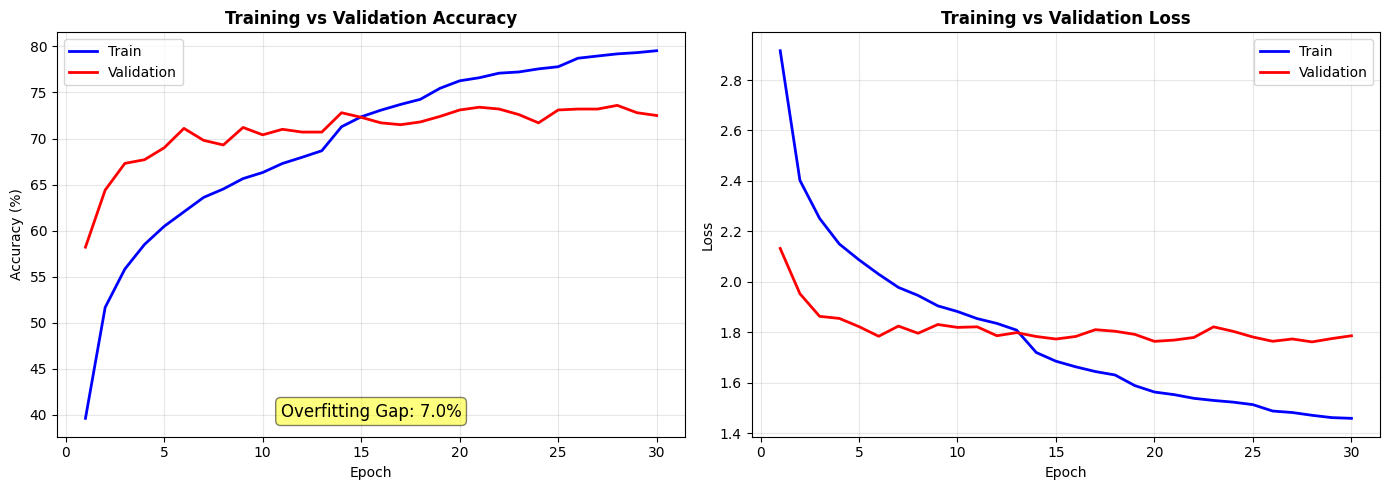


OVERFITTING DIAGNOSIS
Train Accuracy: 79.5%
Val Accuracy: 72.5%
Gap: 7.0%

 MILD OVERFITTING (5-10% gap)
Acceptable for 102-class problem


In [24]:
# Cell 10.5 (NEW): Plot Training Curves to Visualize Overfitting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history['train_acc']) + 1)

# Accuracy plot
ax1.plot(epochs, [acc*100 for acc in history['train_acc']], 'b-', label='Train', linewidth=2)
ax1.plot(epochs, [acc*100 for acc in history['val_acc']], 'r-', label='Validation', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Training vs Validation Accuracy', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add gap annotation
gap = (history['train_acc'][-1] - history['val_acc'][-1]) * 100
ax1.text(0.5, 0.05, f'Overfitting Gap: {gap:.1f}%', 
         transform=ax1.transAxes, fontsize=12, ha='center',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# Loss plot
ax2.plot(epochs, history['train_loss'], 'b-', label='Train', linewidth=2)
ax2.plot(epochs, history['val_loss'], 'r-', label='Validation', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Training vs Validation Loss', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CFG["results_dir"]}/training_curves.png', dpi=150)
plt.show()

# Diagnosis
print('\n' + '='*50)
print('OVERFITTING DIAGNOSIS')
print('='*50)
print(f'Train Accuracy: {history["train_acc"][-1]*100:.1f}%')
print(f'Val Accuracy: {history["val_acc"][-1]*100:.1f}%')
print(f'Gap: {gap:.1f}%')

if gap > 15:
    print('\n SEVERE OVERFITTING (>15% gap)')
    print('Recommendations:')
    print('  1. Use more data augmentation')
    print('  2. Increase weight decay')
    print('  3. Reduce model complexity')
    print('  4. Add more dropout')
elif gap > 10:
    print('\n MODERATE OVERFITTING (10-15% gap)')
    print('Recommendations:')
    print('  1. Add MixUp/CutMix augmentation')
    print('  2. Increase label smoothing')
elif gap > 5:
    print('\n MILD OVERFITTING (5-10% gap)')
    print('Acceptable for 102-class problem')
else:
    print('\n GOOD GENERALIZATION (<5% gap)')

In [25]:
# Cell 11 (IMPROVED): Better Data Augmentation
print('Creating stronger augmentation for training...')

strong_train_transform = A.Compose([
    # Spatial transforms
    A.RandomResizedCrop(size=(CFG['img_size'], CFG['img_size']), scale=(0.5, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    A.Rotate(limit=30, p=0.5),
    
    # Color transforms
    A.OneOf([
        A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2),
    ], p=0.5),
    
    # Blur transforms
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 7)),
        A.GaussNoise(var_limit=(10.0, 50.0)),
    ], p=0.3),
    
    # CutOut - forces model to use full image
    A.CoarseDropout(
        num_holes_range=(1, 8),
        hole_height_range=(1, 30),
        hole_width_range=(1, 30),
        fill=0, p=0.3
    ),
    
    A.Normalize(mean=CFG['mean'], std=CFG['std']),
    ToTensorV2(),
])

# Recreate training dataset with stronger augmentation
train_ds_strong = PestDataset(
    CFG['data_dir'], 
    split='train', 
    transform=strong_train_transform,
    class_names=CFG['class_names'],
    max_samples=None  # Use all data now
)

train_loader_strong = DataLoader(
    train_ds_strong,
    batch_size=CFG['batch_size'],
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

print(f' Strong augmentation ready with {len(train_ds_strong)} training images')
print('   Added: Rotation, Blur, Noise, Stronger Color Jitter, CutOut')

Creating stronger augmentation for training...
Scanning train folder...
[train] 90190 images loaded
 Strong augmentation ready with 90190 training images
   Added: Rotation, Blur, Noise, Stronger Color Jitter, CutOut


In [26]:
# Cell 12 (NEW): Final Training with All Improvements
print('=' * 55)
print('FINAL TRAINING - ALL REGULARIZATION TECHNIQUES')
print('=' * 55)

# Reload best model
checkpoint = torch.load(CFG['checkpoint_path'])
model.load_state_dict(checkpoint['model_state'])
print(f'Loaded model from epoch {checkpoint.get("epoch", "?")} with val_acc: {checkpoint["val_acc"]*100:.2f}%')

# Aggressive regularization
optimizer_final = optim.AdamW([
    {'params': backbone_params, 'lr': 3e-5, 'weight_decay': 0.02},  # Stronger regularization
    {'params': head_params, 'lr': 3e-4, 'weight_decay': 0.005},
])

scheduler_final = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_final, T_0=5, T_mult=1, eta_min=1e-6
)

best_acc_final = 0
patience_final = 0

print('\nTraining with strong augmentation + MixUp + heavy regularization\n')

for epoch in range(1, 16):  # 15 more epochs
    print(f'Epoch {epoch}/15')
    epoch_start = time.time()
    
    # Use strong augmentation + MixUp
    train_loss, train_acc = train_epoch(model, train_loader_strong, optimizer_final, use_mixup=True)
    
    # Validate
    val_loss, val_acc = validate(model, val_loader)
    
    scheduler_final.step()
    current_lr = optimizer_final.param_groups[0]['lr']
    
    if val_acc > best_acc_final:
        best_acc_final = val_acc
        patience_final = 0
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'val_acc': val_acc,
            'train_acc': train_acc,
        }, CFG['checkpoint_path'])
        improved = ' Saved!'
    else:
        patience_final += 1
        improved = f'Patience: {patience_final}/7'
    
    epoch_time = time.time() - epoch_start
    gap = (train_acc - val_acc) * 100
    
    print(f'  Train: {train_acc*100:.1f}% | Val: {val_acc*100:.1f}%')
    print(f'  Gap: {gap:.1f}% | Best: {best_acc_final*100:.1f}% | LR: {current_lr:.6f} {improved}')
    print(f'  Time: {epoch_time:.1f}s\n')
    
    if patience_final >= 7:
        print('Early stopping!')
        break

print(f'\n Final training complete! Best Val Acc: {best_acc_final*100:.2f}%')

FINAL TRAINING - ALL REGULARIZATION TECHNIQUES
Loaded model from epoch 28 with val_acc: 73.60%

Training with strong augmentation + MixUp + heavy regularization

Epoch 1/15
  Batch 20/5637 - Loss: 0.1112 - Acc: 0.778
  Batch 40/5637 - Loss: 0.1445 - Acc: 0.761
  Batch 60/5637 - Loss: 0.6038 - Acc: 0.758
  Batch 80/5637 - Loss: 0.1389 - Acc: 0.742
  Batch 100/5637 - Loss: 0.3430 - Acc: 0.744
  Batch 120/5637 - Loss: 0.0686 - Acc: 0.747
  Batch 140/5637 - Loss: 0.2388 - Acc: 0.760
  Batch 160/5637 - Loss: 0.1392 - Acc: 0.759
  Batch 180/5637 - Loss: 0.2905 - Acc: 0.756
  Batch 200/5637 - Loss: 0.3414 - Acc: 0.758
  Batch 220/5637 - Loss: 0.0933 - Acc: 0.759
  Batch 240/5637 - Loss: 0.4009 - Acc: 0.760
  Batch 260/5637 - Loss: 0.2105 - Acc: 0.761
  Batch 280/5637 - Loss: 0.1347 - Acc: 0.763
  Batch 300/5637 - Loss: 0.0375 - Acc: 0.762
  Batch 320/5637 - Loss: 0.4684 - Acc: 0.767
  Batch 340/5637 - Loss: 0.0545 - Acc: 0.771
  Batch 360/5637 - Loss: 0.2429 - Acc: 0.767
  Batch 380/5637 - Lo

In [27]:
# Cell 13: Final Model Evaluation
print('=' * 60)
print('FINAL MODEL EVALUATION')
print('=' * 60)

# Load the best model
checkpoint = torch.load(CFG['checkpoint_path'], map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
print(f' Loaded best model')
print(f'   Epoch: {checkpoint.get("epoch", "N/A")}')
print(f'   Val Acc: {checkpoint["val_acc"]*100:.2f}%')
print(f'   Train Acc: {checkpoint.get("train_acc", 0)*100:.2f}%')

# Evaluate on test set
model.eval()
all_preds = []
all_labels = []
all_probs = []
test_loss = 0

print('\nRunning inference on test set...')
with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(tqdm(test_loader, desc='Testing')):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        test_loss += loss.item() * images.size(0)
        probs = F.softmax(outputs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate metrics
test_loss = test_loss / len(test_ds)
accuracy = accuracy_score(all_labels, all_preds)

print(f'\n{"="*60}')
print(f'TEST SET RESULTS')
print(f'{"="*60}')
print(f'  Loss:     {test_loss:.4f}')
print(f'  Accuracy: {accuracy*100:.2f}%')
print(f'{"="*60}')

FINAL MODEL EVALUATION
 Loaded best model
   Epoch: 7
   Val Acc: 73.90%
   Train Acc: 77.59%

Running inference on test set...


Testing:   0%|          | 0/32 [00:00<?, ?it/s]


TEST SET RESULTS
  Loss:     0.2515
  Accuracy: 73.60%


In [30]:
# Cell 14: Detailed Metrics & Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score
import seaborn as sns

# Top-K Accuracy
all_probs_array = np.array(all_probs)
all_labels_array = np.array(all_labels)

top1 = accuracy_score(all_labels_array, all_preds)
all_class_labels = list(range(CFG['num_classes']))
top3 = top_k_accuracy_score(all_labels_array, all_probs_array, k=3, labels=all_class_labels)
top5 = top_k_accuracy_score(all_labels_array, all_probs_array, k=5, labels=all_class_labels)

print(f'\n{"="*60}')
print(f'TOP-K ACCURACY')
print(f'{"="*60}')
print(f'  Top-1: {top1*100:.2f}%')
print(f'  Top-3: {top3*100:.2f}%')
print(f'  Top-5: {top5*100:.2f}%')
print(f'{"="*60}')

# Classification Report
print(f'\n{"="*60}')
print(f'PER-CLASS PERFORMANCE')
print(f'{"="*60}')
report = classification_report(
    all_labels_array, all_preds,
    labels=all_class_labels,
    target_names=CFG['class_names'],
    digits=3,
    zero_division=0
)
print(report)

# Save report to file
with open(f"{CFG['results_dir']}/classification_report.txt", 'w') as f:
    f.write(f'Test Loss: {test_loss:.4f}\n')
    f.write(f'Top-1 Accuracy: {top1*100:.2f}%\n')
    f.write(f'Top-3 Accuracy: {top3*100:.2f}%\n')
    f.write(f'Top-5 Accuracy: {top5*100:.2f}%\n\n')
    f.write(report)
print(f' Report saved to {CFG["results_dir"]}/classification_report.txt')


TOP-K ACCURACY
  Top-1: 73.60%
  Top-3: 88.80%
  Top-5: 92.40%

PER-CLASS PERFORMANCE
                                 precision    recall  f1-score   support

               rice leaf roller      0.727     1.000     0.842         8
          rice leaf caterpillar      0.333     0.250     0.286         4
              paddy stem maggot      0.500     0.250     0.333         4
             asiatic rice borer      0.385     0.385     0.385        13
              yellow rice borer      0.500     0.600     0.545         5
                rice gall midge      0.571     1.000     0.727         4
                   Rice Stemfly      0.143     0.333     0.200         3
             brown plant hopper      0.545     0.462     0.500        13
      white backed plant hopper      0.533     0.727     0.615        11
       small brown plant hopper      0.400     0.333     0.364         6
              rice water weevil      0.692     0.818     0.750        11
                rice leafhopper     

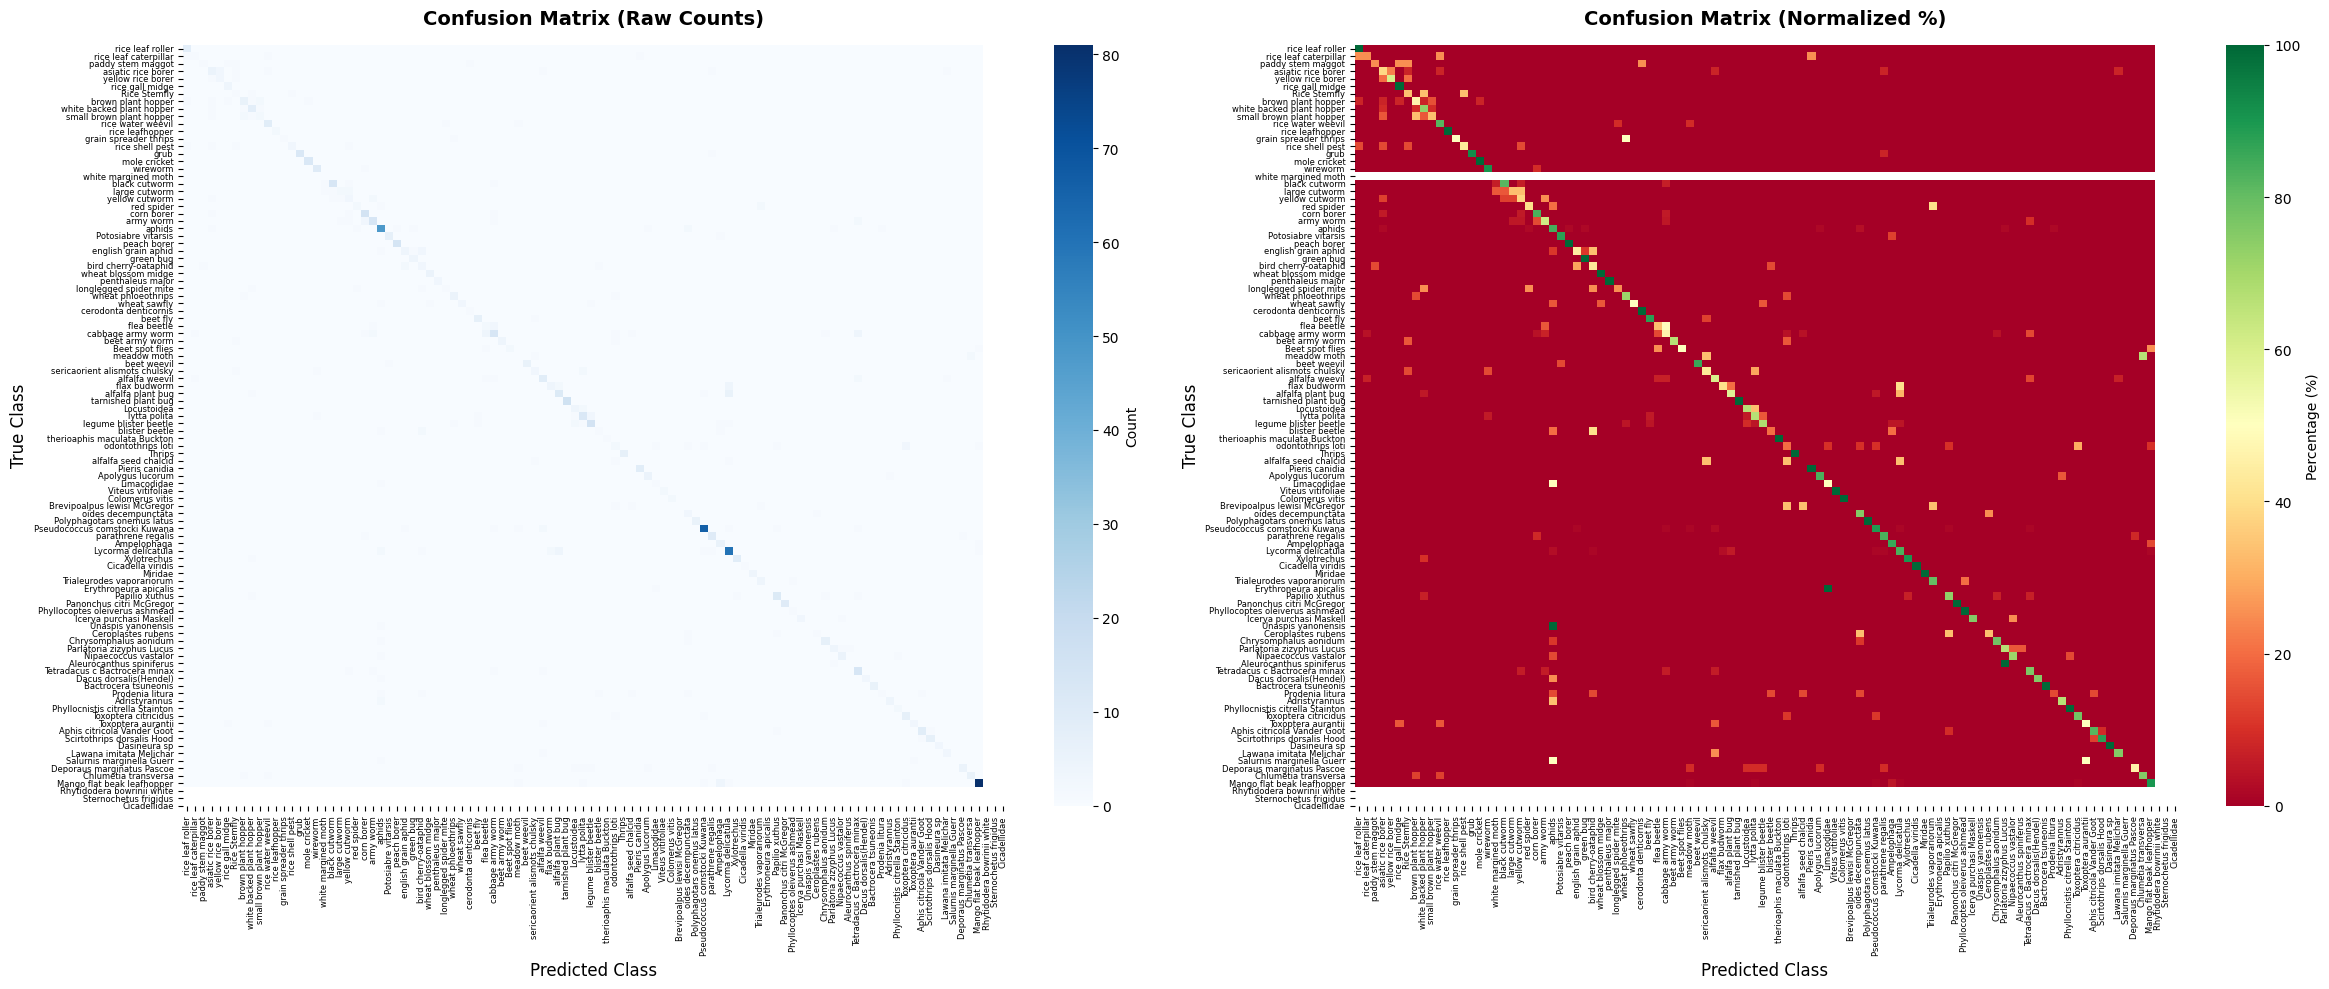

 Confusion matrix saved to ./results/confusion_matrix.png


In [31]:
# Cell 15: Confusion Matrix Visualization
# Calculate confusion matrix
cm = confusion_matrix(all_labels_array, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

# Raw counts
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', 
            xticklabels=CFG['class_names'], 
            yticklabels=CFG['class_names'],
            ax=ax1, cbar_kws={'label': 'Count'})
ax1.set_title('Confusion Matrix (Raw Counts)', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Predicted Class', fontsize=12)
ax1.set_ylabel('True Class', fontsize=12)
ax1.tick_params(axis='x', rotation=90, labelsize=6)
ax1.tick_params(axis='y', rotation=0, labelsize=6)

# Normalized (percentage)
sns.heatmap(cm_normalized, annot=False, fmt='.1f', cmap='RdYlGn', 
            xticklabels=CFG['class_names'], 
            yticklabels=CFG['class_names'],
            ax=ax2, cbar_kws={'label': 'Percentage (%)'},
            vmin=0, vmax=100)
ax2.set_title('Confusion Matrix (Normalized %)', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Predicted Class', fontsize=12)
ax2.set_ylabel('True Class', fontsize=12)
ax2.tick_params(axis='x', rotation=90, labelsize=6)
ax2.tick_params(axis='y', rotation=0, labelsize=6)

plt.tight_layout()
plt.savefig(f"{CFG['results_dir']}/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print(f' Confusion matrix saved to {CFG["results_dir"]}/confusion_matrix.png')

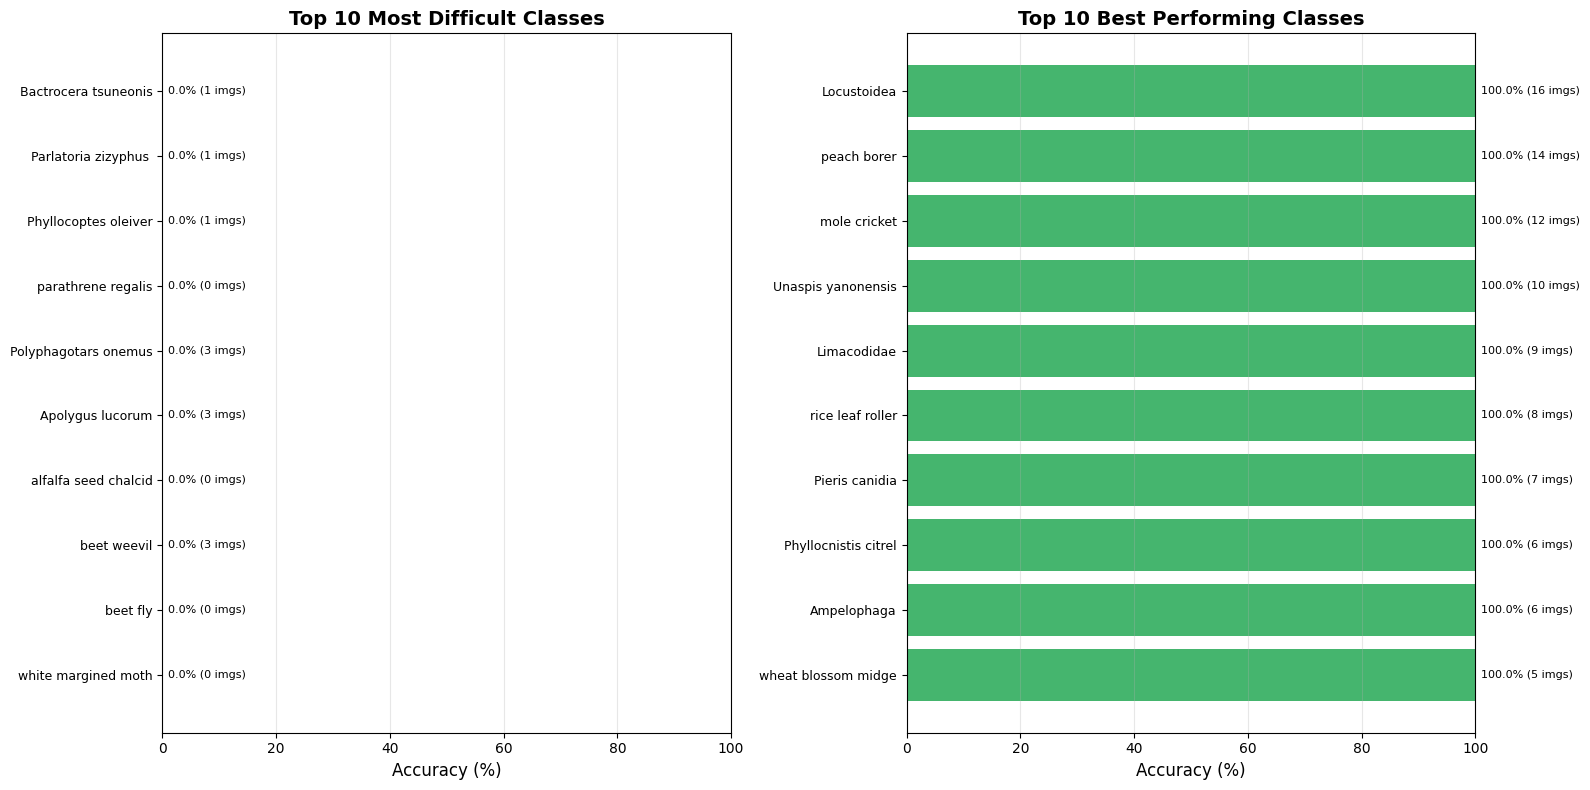

 Class performance analysis saved


In [32]:
# Cell 16: Best & Worst Classes Analysis
# Find per-class accuracy
class_correct = np.zeros(CFG['num_classes'])
class_total = np.zeros(CFG['num_classes'])

for label, pred in zip(all_labels_array, all_preds):
    class_total[label] += 1
    if label == pred:
        class_correct[label] += 1

class_acc = class_correct / (class_total + 1e-8) * 100

# Sort classes by accuracy
class_performance = list(zip(CFG['class_names'], class_acc, class_total))
class_performance.sort(key=lambda x: x[1])

# Plot top 10 best and worst
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Worst 10 classes
worst = class_performance[:10]
names_worst = [x[0][:20] for x in worst]
accs_worst = [x[1] for x in worst]
samples_worst = [x[2] for x in worst]

bars1 = ax1.barh(range(len(names_worst)), accs_worst, color='#DC2626', alpha=0.8)
ax1.set_yticks(range(len(names_worst)))
ax1.set_yticklabels(names_worst, fontsize=9)
ax1.set_xlabel('Accuracy (%)', fontsize=12)
ax1.set_title('Top 10 Most Difficult Classes', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 100)
ax1.grid(axis='x', alpha=0.3)

# Add sample counts
for i, (acc, samples) in enumerate(zip(accs_worst, samples_worst)):
    ax1.text(acc + 1, i, f'{acc:.1f}% ({int(samples)} imgs)', va='center', fontsize=8)

# Best 10 classes
best = class_performance[-10:]
names_best = [x[0][:20] for x in best]
accs_best = [x[1] for x in best]
samples_best = [x[2] for x in best]

bars2 = ax2.barh(range(len(names_best)), accs_best, color='#16A34A', alpha=0.8)
ax2.set_yticks(range(len(names_best)))
ax2.set_yticklabels(names_best, fontsize=9)
ax2.set_xlabel('Accuracy (%)', fontsize=12)
ax2.set_title('Top 10 Best Performing Classes', fontsize=14, fontweight='bold')
ax2.set_xlim(0, 100)
ax2.grid(axis='x', alpha=0.3)

for i, (acc, samples) in enumerate(zip(accs_best, samples_best)):
    ax2.text(acc + 1, i, f'{acc:.1f}% ({int(samples)} imgs)', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f"{CFG['results_dir']}/class_performance.png", dpi=150, bbox_inches='tight')
plt.show()
print(f' Class performance analysis saved')

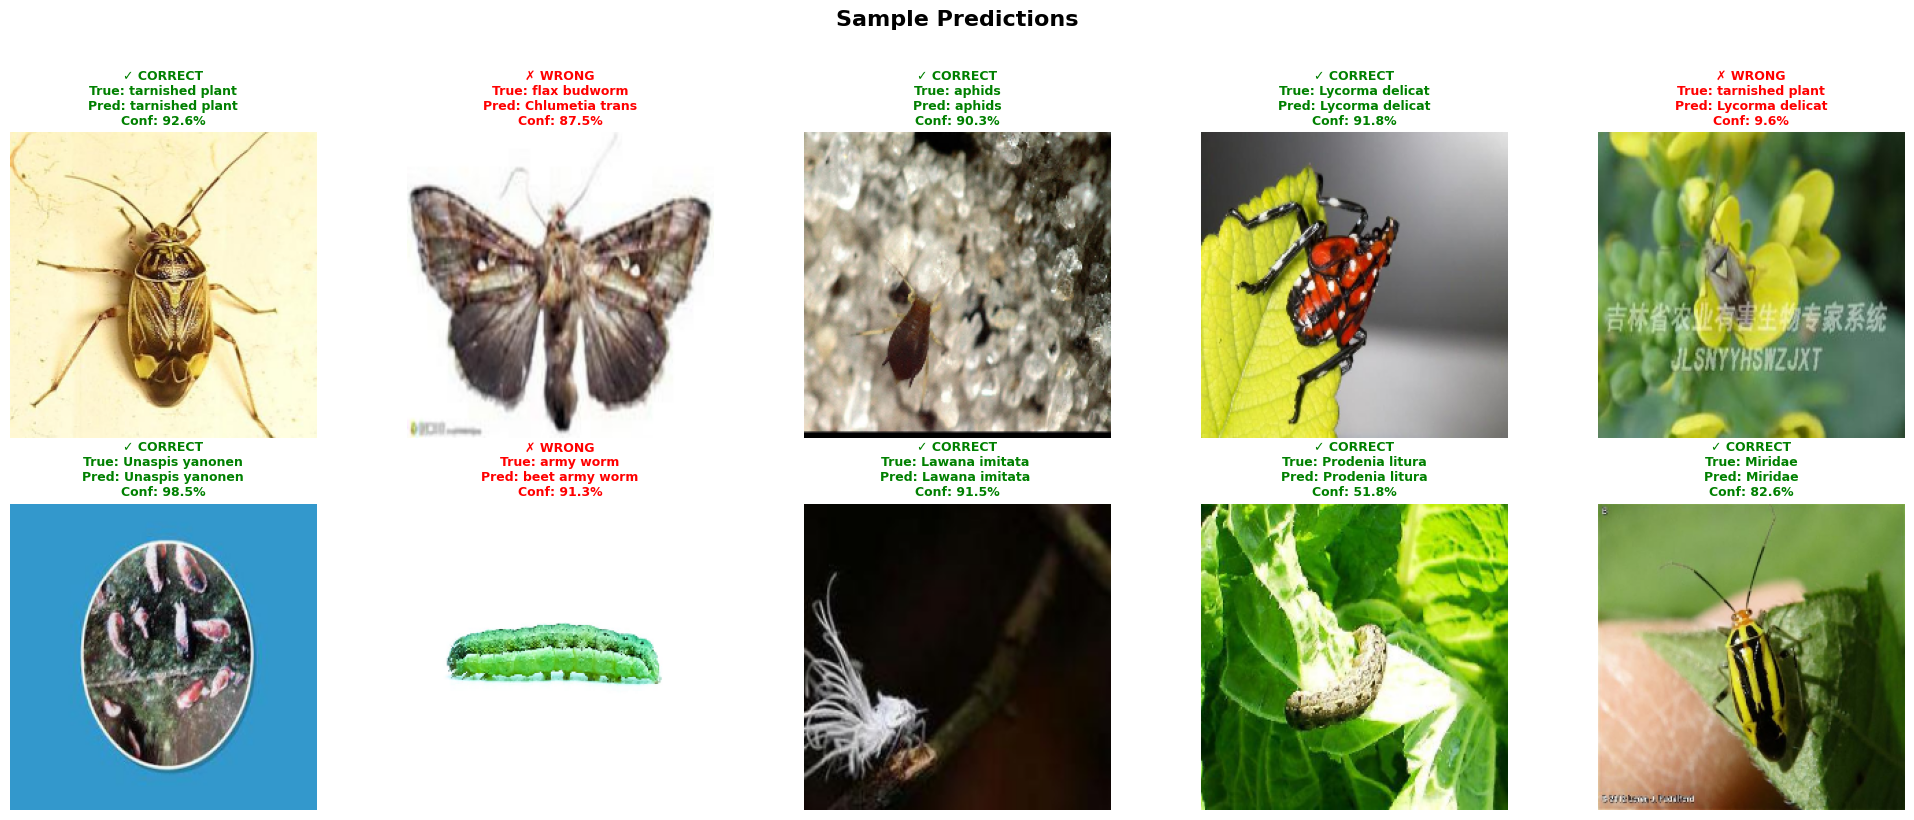

 Sample predictions saved


In [33]:
# Cell 17: Sample Predictions Visualization
def visualize_predictions(model, dataset, num_samples=10):
    """Show sample predictions with confidence scores"""
    model.eval()
    
    # Get random samples
    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))
    
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        img_path, true_label = dataset.samples[idx]
        
        # Load and preprocess image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Get prediction
        img_tensor = val_transform(image=img)['image'].unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            output = model(img_tensor)
            probs = F.softmax(output, dim=1)[0]
            pred_label = probs.argmax().item()
            confidence = probs[pred_label].item()
        
        # Show image
        axes[i].imshow(cv2.resize(img, (224, 224)))
        axes[i].axis('off')
        
        # Color based on correctness
        if pred_label == true_label:
            color = 'green'
            status = '✓ CORRECT'
        else:
            color = 'red'
            status = '✗ WRONG'
        
        true_name = CFG['class_names'][true_label][:15]
        pred_name = CFG['class_names'][pred_label][:15]
        
        axes[i].set_title(f'{status}\nTrue: {true_name}\nPred: {pred_name}\nConf: {confidence*100:.1f}%',
                         fontsize=9, color=color, fontweight='bold')
    
    plt.suptitle('Sample Predictions', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f"{CFG['results_dir']}/sample_predictions.png", dpi=150, bbox_inches='tight')
    plt.show()

# Visualize
visualize_predictions(model, test_ds, num_samples=10)
print(f' Sample predictions saved')

In [34]:
# Cell 18: Save Model for Deployment
print('=' * 60)
print('SAVING MODEL FOR DEPLOYMENT')
print('=' * 60)

# Save PyTorch checkpoint (for continued training)
torch.save({
    'model_state': model.state_dict(),
    'optimizer_state': optimizer.state_dict() if 'optimizer' in dir() else None,
    'class_names': CFG['class_names'],
    'num_classes': CFG['num_classes'],
    'img_size': CFG['img_size'],
    'mean': CFG['mean'],
    'std': CFG['std'],
    'test_accuracy': accuracy,
    'top3_accuracy': top3,
    'top5_accuracy': top5,
    'architecture': 'ResNet50',
    'config': CFG,
}, f"{CFG['results_dir']}/pest_resnet50_checkpoint.pth")
print(f' Checkpoint saved: {CFG["results_dir"]}/pest_resnet50_checkpoint.pth')

# Save just the model weights (for inference)
torch.save(model.state_dict(), f"{CFG['results_dir']}/pest_resnet50_weights.pth")
print(f' Weights saved: {CFG["results_dir"]}/pest_resnet50_weights.pth')

# Save the entire model (less flexible but easier for quick deployment)
torch.save(model, f"{CFG['results_dir']}/pest_resnet50_full_model.pth")
print(f' Full model saved: {CFG["results_dir"]}/pest_resnet50_full_model.pth')

SAVING MODEL FOR DEPLOYMENT
 Checkpoint saved: ./results/pest_resnet50_checkpoint.pth
 Weights saved: ./results/pest_resnet50_weights.pth
 Full model saved: ./results/pest_resnet50_full_model.pth


In [ ]:
# Cell 19: Export to ONNX (for production deployment)
try:
    print('\nExporting to ONNX format...')
    model.eval()

    # Ensure ONNX export dependencies are available in this notebook kernel.
    import onnx
    import onnxscript

    # Create dummy input
    dummy_input = torch.randn(1, 3, CFG['img_size'], CFG['img_size']).to(DEVICE)

    onnx_path = f"{CFG['results_dir']}/pest_resnet50.onnx"

    torch.onnx.export(
        model,
        dummy_input,
        onnx_path,
        export_params=True,
        opset_version=11,
        do_constant_folding=True,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={
            'input': {0: 'batch_size'},
            'output': {0: 'batch_size'}
        }
    )
    print(f' ONNX model exported: {onnx_path}')

    # Verify ONNX model
    onnx_model = onnx.load(onnx_path)
    onnx.checker.check_model(onnx_model)
    print(' ONNX model verified successfully')

except Exception as e:
    print(f'  ONNX export failed: {e}')
    print('   Install in notebook kernel: %pip install onnx onnxscript')


Exporting to ONNX format...
  ONNX export failed: No module named 'onnxscript'
   Install onnx: pip install onnx


In [ ]:
# Cell 20: Single Image Inference Function
def predict_single_image(image_path, model, class_names, transform, device, top_k=5):
    """
    Predict pest class for a single image
    
    Args:
        image_path: Path to image file
        model: Trained model
        class_names: List of class names
        transform: Image transform pipeline
        device: torch device
        top_k: Number of top predictions to return
    
    Returns:
        List of (class_name, probability) tuples
    """
    model.eval()
    
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not load image: {image_path}")
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Transform
    img_tensor = transform(image=img)['image'].unsqueeze(0).to(device)
    
    # Predict
    with torch.no_grad():
        output = model(img_tensor)
        probs = F.softmax(output, dim=1)[0]
    
    # Get top-k predictions
    top_probs, top_indices = torch.topk(probs, k=min(top_k, len(class_names)))
    
    results = []
    for prob, idx in zip(top_probs.cpu().numpy(), top_indices.cpu().numpy()):
        results.append((class_names[idx], float(prob)))
    
    return results

# Example usage
print('=' * 60)
print('SINGLE IMAGE INFERENCE TEST')
print('=' * 60)

# Test on a random test image
if len(test_ds) > 0:
    test_img_path = test_ds.samples[0][0]
    true_label = test_ds.samples[0][1]
    
    print(f'Image: {Path(test_img_path).name}')
    print(f'True class: {CFG["class_names"][true_label]}')
    print(f'\nTop 5 predictions:')
    print('-' * 40)
    
    predictions = predict_single_image(
        test_img_path, model, CFG['class_names'], 
        val_transform, DEVICE, top_k=5
    )
    
    for rank, (class_name, prob) in enumerate(predictions, 1):
        bar = '█' * int(prob * 30)
        correct = '✓' if class_name == CFG['class_names'][true_label] else ' '
        print(f'  {rank}. {correct} {class_name:<30} {prob*100:5.1f}%  {bar}')
    
    print('-' * 40)

print(f'\n Inference function ready for use')

In [ ]:
# Cell 21: Generate Project Summary
print('\n')
print('=' * 70)
print(' PEST IDENTIFICATION PROJECT - COMPLETE SUMMARY')
print('=' * 70)

print(f'\n MODEL ARCHITECTURE:')
print(f'   • Base: ResNet-50 (pretrained on ImageNet)')
print(f'   • Head: Dropout → 2048 → 512 → ReLU → Dropout → 102 classes')
print(f'   • Total Parameters: {sum(p.numel() for p in model.parameters()):,}')

print(f'\n PERFORMANCE METRICS:')
print(f'   • Test Accuracy (Top-1): {top1*100:.2f}%')
print(f'   • Test Accuracy (Top-3): {top3*100:.2f}%')
print(f'   • Test Accuracy (Top-5): {top5*100:.2f}%')
print(f'   • Test Loss: {test_loss:.4f}')

print(f'\n TRAINING TECHNIQUES USED:')
print(f'   • Two-phase training (head warmup + full fine-tuning)')
print(f'   • Focal Loss with label smoothing (γ=2.0)')
print(f'   • MixUp data augmentation (α=0.2)')
print(f'   • Differential learning rates (backbone: 3e-5, head: 3e-4)')
print(f'   • Cosine annealing learning rate scheduler')
print(f'   • Gradient clipping (max_norm=1.0)')
print(f'   • Weight decay regularization (0.01-0.02)')
print(f'   • Strong data augmentation (rotation, blur, cutout, color jitter)')
print(f'   • Early stopping (patience=7)')

print(f'\n DATASET DETAILS:')
print(f'   • Name: IP102 (Insect Pest 102)')
print(f'   • Total Classes: {CFG["num_classes"]}')
print(f'   • Training Images: {len(train_ds)}')
print(f'   • Validation Images: {len(val_ds)}')
print(f'   • Test Images: {len(test_ds)}')
print(f'   • Image Size: {CFG["img_size"]}×{CFG["img_size"]}')

print(f'\n SAVED FILES:')
import os
results_files = os.listdir(CFG['results_dir'])
for file in sorted(results_files):
    file_path = os.path.join(CFG['results_dir'], file)
    size = os.path.getsize(file_path) / (1024*1024)  # MB
    print(f'   • {file} ({size:.1f} MB)')

print(f'\n DEPLOYMENT OPTIONS:')
print(f'   1. PyTorch: Load pest_resnet50_weights.pth')
print(f'   2. ONNX: Use pest_resnet50.onnx for production')
print(f'   3. Full model: Load pest_resnet50_full_model.pth')

print(f'\n TOP PERFORMING CLASSES:')
for class_name, acc, count in best[-5:]:
    print(f'   • {class_name:<30} {acc:.1f}% ({int(count)} samples)')

print(f'\n MOST CHALLENGING CLASSES:')
for class_name, acc, count in worst[:5]:
    print(f'   • {class_name:<30} {acc:.1f}% ({int(count)} samples)')

print(f'\n{"="*70}')
print(f' PROJECT READY FOR RESUME & DEPLOYMENT!')
print(f'{"="*70}\n')

In [ ]:
# Cell 22: Verify ONNX export dependencies
import onnx
import onnxscript
print('onnx version      :', onnx.__version__)
print('onnxscript import : OK')